In [90]:
df = pd.read_csv(r"C:\Users\Muviniish\Machine Learning\CW1\Dataset\customer_shopping_behavior.csv")
missing = df.isnull().sum()
missing = missing[missing > 0]

pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": (missing / len(df) * 100).round(2)
})

,Missing Values,Percentage (%)
Purchase Amount (USD),556,11.01
Size,370,7.33
Review Rating,601,11.90
Previous Purchases,548,10.85


In [28]:
duplicates = df[df.duplicated(keep=False)]

print("Total Duplicate Records:", df.duplicated().sum())

display(
    duplicates.sort_values("Customer ID").head(6)
)

Total Duplicate Records: 50


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
2189,172,29,Male,Shorts,Clothing,35.0,Virginia,M,Blue,Summer,3.6,Yes,Store Pickup,Yes,4.0,Credit Card,Weekly
3698,172,29,Male,Shorts,Clothing,35.0,Virginia,M,Blue,Summer,3.6,Yes,Store Pickup,Yes,4.0,Credit Card,Weekly
4059,227,29,Male,Shoes,Footwear,74.0,Texas,L,Violet,Spring,3.3,Yes,Free Shipping,Yes,5.0,PayPal,Monthly
1569,227,29,Male,Shoes,Footwear,74.0,Texas,L,Violet,Spring,3.3,Yes,Free Shipping,Yes,5.0,PayPal,Monthly
3036,258,20,Male,Handbag,Accessories,53.0,West Virginia,M,Red,Summer,4.5,Yes,Express,Yes,5.0,Credit Card,Quarterly
732,258,20,Male,Handbag,Accessories,53.0,West Virginia,M,Red,Summer,4.5,Yes,Express,Yes,5.0,Credit Card,Quarterly


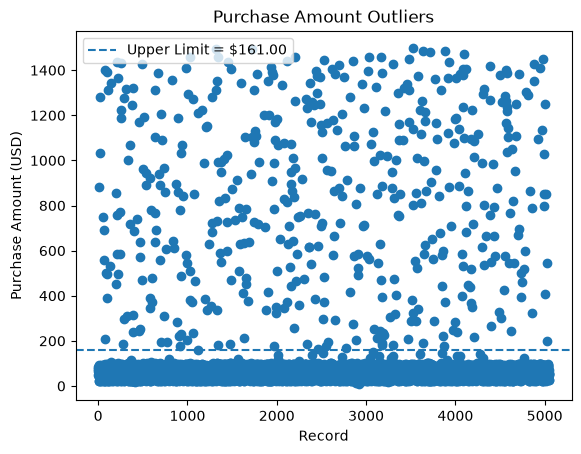

In [34]:
plt.scatter(
    range(len(df)),
    df["Purchase Amount (USD)"]
)

plt.axhline(upper_limit, linestyle="--",
            label=f"Upper Limit = ${upper_limit:.2f}")

plt.legend()
plt.title("Purchase Amount Outliers")
plt.xlabel("Record")
plt.ylabel("Purchase Amount (USD)")
plt.show()

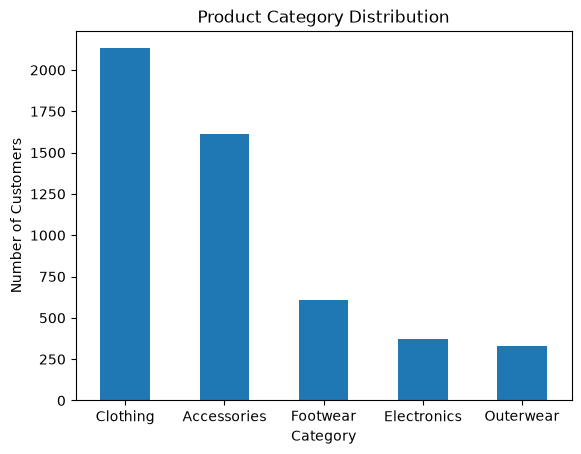

In [84]:
df["Category"].value_counts().plot(kind="bar")
plt.title("Product Category Distribution")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

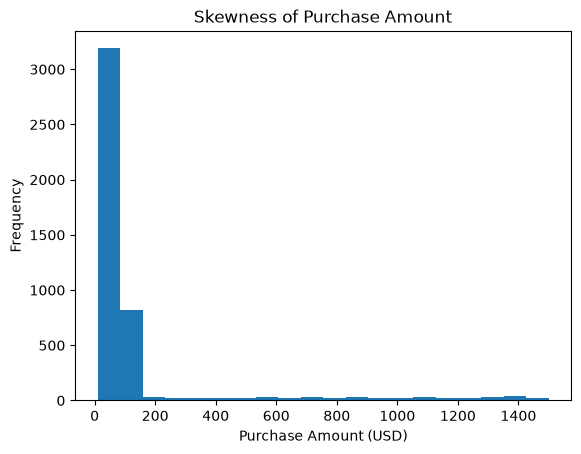

Skewness: 3.3454377364917365


In [50]:
plt.hist(df["Purchase Amount (USD)"].dropna(), bins=20)

plt.title("Skewness of Purchase Amount")
plt.xlabel("Purchase Amount (USD)")
plt.ylabel("Frequency")
plt.show()

print("Skewness:", df["Purchase Amount (USD)"].skew())

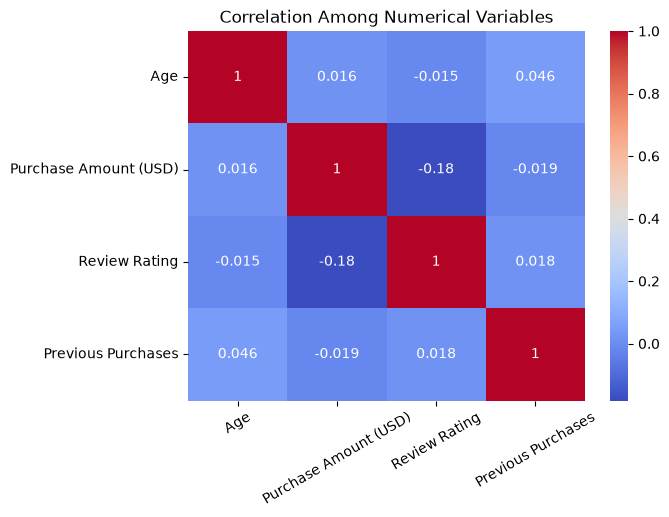

In [83]:
import seaborn as sns
numeric = df.select_dtypes(include="number").drop(columns="Customer ID")
corr = numeric.corr()
sns.heatmap(
    corr,
    annot=True,       # Show correlation values
    cmap="coolwarm"
)
plt.title("Correlation Among Numerical Variables")
plt.xticks(rotation=30)
plt.show()

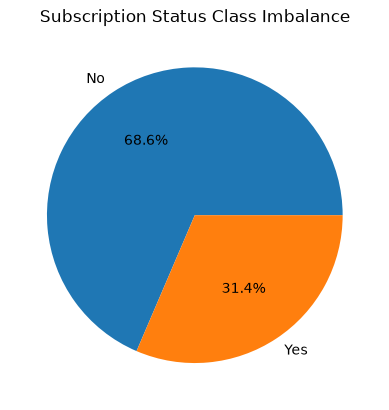

In [62]:
df["Subscription Status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Subscription Status Class Imbalance")
plt.show()

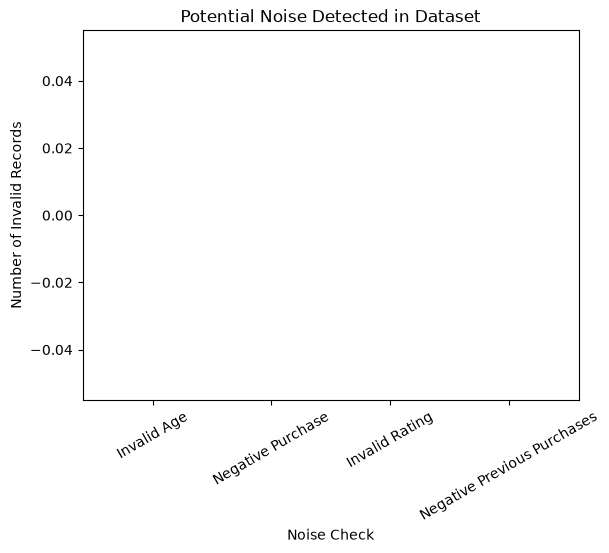

In [77]:
noise = {
    "Invalid Age": (df["Age"] < 18).sum(),
    "Negative Purchase": (df["Purchase Amount (USD)"] < 0).sum(),
    "Invalid Rating": ((df["Review Rating"] < 1) |
                       (df["Review Rating"] > 5)).sum(),
    "Negative Previous Purchases": (df["Previous Purchases"] < 0).sum()
}
plt.bar(noise.keys(), noise.values())
plt.title("Potential Noise Detected in Dataset")
plt.xlabel("Noise Check")
plt.ylabel("Number of Invalid Records")
plt.xticks(rotation=30)
plt.show()

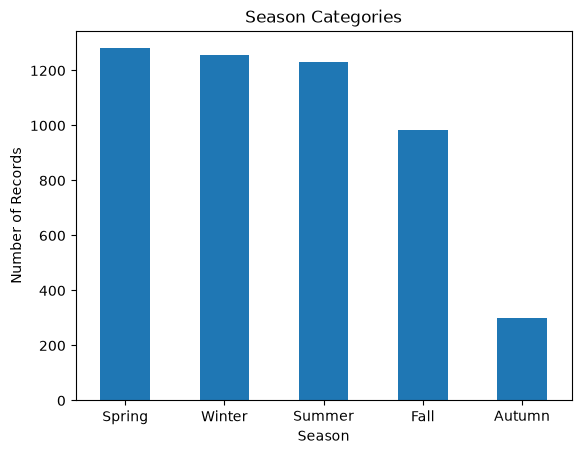

In [82]:
df["Season"].value_counts().plot(kind="bar")

plt.title("Season Categories")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()